# 01 — Cluster-Then-Classify

Two-phase training: use backprop with a **differentiable clustering loss** to learn
representations, then freeze the backbone and train a classification head.

**Phase 1 — Clustering:** Train a 784→128→64 backbone where the loss directly
optimizes for cluster structure (intra-class condensation + inter-class separation
via centroid distances). No classification head — the network learns to cluster
purely through gradient descent on geometric objectives.

**Phase 2 — Classification:** Freeze fc1 and fc2, attach a 64→10 linear head,
and train only the classifier with CrossEntropyLoss on the frozen features.

**Key question:** Can backprop-driven clustering produce representations that
are as good (or better) than the direct geometric nudging from CentroidProjection?

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

from scripts.viz_export import ExperimentTracker

import numpy as np
from sklearn.metrics import silhouette_score

torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"PyTorch {torch.__version__}")
device = torch.device("cpu")

/Users/morgancooper/miniconda3/envs/nnpo/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.10.0


## 1. Load MNIST

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: x.view(-1)),
])

data_root = os.path.join(PROJECT_ROOT, "data")
full_train_dataset = datasets.MNIST(root=data_root, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root=data_root, train=False, download=True, transform=transform)

train_dataset, val_dataset = random_split(
    full_train_dataset, [48000, 12000],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, generator=torch.Generator().manual_seed(0))
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 48000, Val: 12000, Test: 10000


## 2. Define Model & Clustering Loss

In [3]:
# --- Hyperparameters ---
MARGIN = 10.0          # Target minimum distance between centroids
INTRA_WEIGHT = 1.0     # Weight for intra-class condensation loss
INTER_WEIGHT = 0.5     # Weight for inter-class separation loss
LR = 0.001
WEIGHT_DECAY = 1e-4    # L2 regularization (Adam)
L1_LAMBDA = 1e-4       # L1 regularization
DROPOUT = 0.3
EPOCHS_PHASE1 = 10
EPOCHS_PHASE2 = 10
CHECKPOINT_EVERY = 10   # Save checkpoint every N batches


class ClusterNet(nn.Module):
    """Two-phase model: clustering backbone + optional classifier head.

    Cumulative regularization stack: BN + LN + Dropout + L1 + L2
    (matches experiment 01 for fair comparison)
    """

    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.drop1 = nn.Dropout(DROPOUT)
        self.fc2 = nn.Linear(128, 64)
        self.ln2 = nn.LayerNorm(64)
        self.drop2 = nn.Dropout(DROPOUT)
        self.fc3 = None  # Added in Phase 2

    def forward(self, x):
        x = self.drop1(torch.relu(self.bn1(self.fc1(x))))
        x = self.drop2(torch.relu(self.ln2(self.fc2(x))))
        if self.fc3 is not None:
            x = self.fc3(x)
        return x

    def freeze_backbone(self):
        for param in self.fc1.parameters():
            param.requires_grad = False
        for param in self.fc2.parameters():
            param.requires_grad = False
        for param in self.bn1.parameters():
            param.requires_grad = False
        for param in self.ln2.parameters():
            param.requires_grad = False

    def add_classifier(self):
        self.fc3 = nn.Linear(64, 10)


def clustering_loss(embeddings, labels, num_classes=10, margin=10.0):
    """Differentiable clustering loss: intra-class pull + inter-class push.

    Intra: minimize mean squared distance of each sample to its class centroid.
    Inter: margin-based hinge loss pushing all centroid pairs at least `margin` apart.
    """
    centroids = torch.zeros(num_classes, embeddings.size(1), device=embeddings.device)
    present = torch.zeros(num_classes, dtype=torch.bool, device=embeddings.device)

    for c in range(num_classes):
        mask = (labels == c)
        if mask.any():
            centroids[c] = embeddings[mask].mean(dim=0)
            present[c] = True

    # Intra-class: pull samples toward their centroid
    targets = centroids[labels]
    intra = ((embeddings - targets) ** 2).sum(dim=1).mean()

    # Inter-class: push centroids apart
    active = centroids[present]
    n = active.size(0)
    if n < 2:
        return intra, torch.tensor(0.0, device=embeddings.device)

    dists = torch.cdist(active.unsqueeze(0), active.unsqueeze(0)).squeeze(0)
    tri = torch.triu(torch.ones(n, n, device=embeddings.device), diagonal=1).bool()
    inter = torch.relu(margin - dists[tri]).mean()

    return intra, inter


model = ClusterNet().to(device)
print(f"Margin: {MARGIN}, Intra weight: {INTRA_WEIGHT}, Inter weight: {INTER_WEIGHT}")
print(f"L2 weight_decay: {WEIGHT_DECAY}, L1 lambda: {L1_LAMBDA}, Dropout: {DROPOUT}")
print(model)

Margin: 10.0, Intra weight: 1.0, Inter weight: 0.5
L2 weight_decay: 0.0001, L1 lambda: 0.0001, Dropout: 0.3
ClusterNet(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (drop2): Dropout(p=0.3, inplace=False)
)


## 3. Pick Input Samples & Viz Samples

In [4]:
# 5 input samples: one per distinct digit (first 5 unique)
seen_labels = set()
five_images, five_labels = [], []
for img, label in full_train_dataset:
    if label not in seen_labels:
        five_images.append(img)
        five_labels.append(int(label))
        seen_labels.add(label)
    if len(seen_labels) == 5:
        break
five_images = torch.stack(five_images)
print(f"Input samples: labels={five_labels}, shape={five_images.shape}")

# 500 viz samples: 50 per class
viz_images, viz_labels = [], []
class_counts = {c: 0 for c in range(10)}
for img, label in full_train_dataset:
    label = int(label)
    if class_counts[label] < 50:
        viz_images.append(img)
        viz_labels.append(label)
        class_counts[label] += 1
    if all(v >= 50 for v in class_counts.values()):
        break
viz_images = torch.stack(viz_images)
print(f"Viz samples: {len(viz_labels)} total, shape={viz_images.shape}")

Input samples: labels=[5, 0, 4, 1, 9], shape=torch.Size([5, 784])
Viz samples: 500 total, shape=torch.Size([500, 784])


## 4. Phase 1 — Clustering Pre-Training

Train fc1 and fc2 using only the clustering loss (no classification objective).
The network learns representations where same-class samples cluster together
and different-class centroids are pushed apart.

In [5]:
tracker1 = ExperimentTracker(
    run_id="cluster_pretrain",
    model_name="Cluster Pre-Train (Phase 1)",
    description="784→128→64 backbone with BN+LN+Dropout, trained with clustering loss",
    hyperparameters={
        "lr": LR, "batch_size": 512, "epochs": EPOCHS_PHASE1,
        "margin": MARGIN, "intra_weight": INTRA_WEIGHT, "inter_weight": INTER_WEIGHT,
        "weight_decay": WEIGHT_DECAY, "l1_lambda": L1_LAMBDA, "dropout": DROPOUT,
        "phase": 1,
    },
    model=model,
)

tracker1.track("input", size=784)
tracker1.track("hidden_1", model.fc1, size=128)
tracker1.track("hidden_2", model.fc2, size=64)

tracker1.set_input_samples(five_images, five_labels)
tracker1.set_viz_samples(viz_images, viz_labels)
tracker1.enable_gradient_capture()

# Wrap clustering loss as a criterion for loss landscape computation
def cluster_criterion(embeddings, labels):
    intra, inter = clustering_loss(embeddings, labels, margin=MARGIN)
    return INTRA_WEIGHT * intra + INTER_WEIGHT * inter

tracker1.enable_loss_landscape()

ExperimentTracker: will write to /Users/morgancooper/NeuralNetworkProjectionOperator/scripts/../experimentation/runs/cluster_pretrain_v2


In [6]:
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def evaluate_clustering(loader):
    model.eval()
    total_intra = total_inter = 0.0
    n = 0
    with torch.no_grad():
        for x, y in loader:
            emb = model(x)
            intra, inter = clustering_loss(emb, y, margin=MARGIN)
            total_intra += intra.item()
            total_inter += inter.item()
            n += 1
    return total_intra / n, total_inter / n

history1 = {"epoch": [], "train_intra": [], "train_inter": [], "train_total": [], "val_intra": [], "val_inter": [], "val_total": []}
step = 0
global_batch = 0

for epoch in range(EPOCHS_PHASE1):
    model.train()
    running_intra = 0.0
    running_inter = 0.0

    for batch_idx, (batch_x, batch_y) in enumerate(train_loader):
        optimizer.zero_grad()
        embeddings = model(batch_x)
        intra, inter = clustering_loss(embeddings, batch_y, margin=MARGIN)
        l1_norm = sum(p.abs().sum() for p in model.parameters())
        loss = INTRA_WEIGHT * intra + INTER_WEIGHT * inter + L1_LAMBDA * l1_norm

        loss.backward()
        tracker1.capture_gradients()
        optimizer.step()

        running_intra += intra.item()
        running_inter += inter.item()
        global_batch += 1

        if global_batch % CHECKPOINT_EVERY == 0:
            val_intra, val_inter = evaluate_clustering(val_loader)
            tracker1.compute_loss_landscape(batch_x, batch_y, cluster_criterion)
            tracker1.save_checkpoint(step=step, epoch=epoch, metrics={
                "train_intra": running_intra / (batch_idx + 1),
                "train_inter": running_inter / (batch_idx + 1),
                "train_loss": (INTRA_WEIGHT * running_intra + INTER_WEIGHT * running_inter) / (batch_idx + 1),
                "val_intra": val_intra,
                "val_inter": val_inter,
                "val_loss": INTRA_WEIGHT * val_intra + INTER_WEIGHT * val_inter,
            })
            step += 1
            model.train()

    avg_intra = running_intra / len(train_loader)
    avg_inter = running_inter / len(train_loader)
    print(f"Epoch {epoch}: intra={avg_intra:.4f}, inter={avg_inter:.4f}, total={INTRA_WEIGHT * avg_intra + INTER_WEIGHT * avg_inter:.4f}")

    val_intra, val_inter = evaluate_clustering(val_loader)
    history1["epoch"].append(epoch)
    history1["train_intra"].append(avg_intra)
    history1["train_inter"].append(avg_inter)
    history1["train_total"].append(INTRA_WEIGHT * avg_intra + INTER_WEIGHT * avg_inter)
    history1["val_intra"].append(val_intra)
    history1["val_inter"].append(val_inter)
    history1["val_total"].append(INTRA_WEIGHT * val_intra + INTER_WEIGHT * val_inter)

print(f"\nPhase 1 complete — {step} checkpoints saved")

  step_000.json (epoch=0, loss=6.5417, acc=0.0000, size=4.9MB)
  step_001.json (epoch=0, loss=5.2642, acc=0.0000, size=4.9MB)
  step_002.json (epoch=0, loss=5.0293, acc=0.0000, size=4.9MB)
  step_003.json (epoch=0, loss=4.9532, acc=0.0000, size=4.9MB)
  step_004.json (epoch=0, loss=4.9086, acc=0.0000, size=4.9MB)
  step_005.json (epoch=0, loss=4.8731, acc=0.0000, size=4.9MB)
  step_006.json (epoch=0, loss=4.8446, acc=0.0000, size=5.0MB)
  step_007.json (epoch=0, loss=4.8185, acc=0.0000, size=5.0MB)
  step_008.json (epoch=0, loss=4.8062, acc=0.0000, size=5.0MB)
Epoch 0: intra=9.1353, inter=8.6157, total=13.4431
  step_009.json (epoch=1, loss=4.8040, acc=0.0000, size=5.0MB)
  step_010.json (epoch=1, loss=4.8010, acc=0.0000, size=5.0MB)
  step_011.json (epoch=1, loss=4.7921, acc=0.0000, size=5.0MB)
  step_012.json (epoch=1, loss=4.7829, acc=0.0000, size=5.0MB)
  step_013.json (epoch=1, loss=4.7788, acc=0.0000, size=5.0MB)
  step_014.json (epoch=1, loss=4.7747, acc=0.0000, size=5.0MB)
  st

### Phase 1 Training Curves

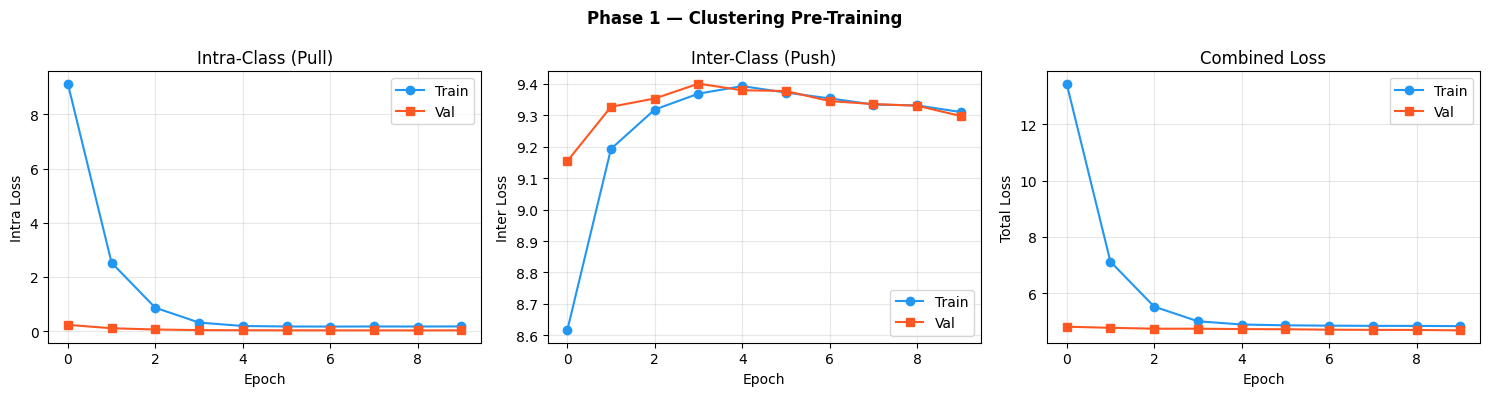

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = history1["epoch"]

ax = axes[0]
ax.plot(epochs, history1["train_intra"], "o-", label="Train", color="#2196F3")
ax.plot(epochs, history1["val_intra"], "s-", label="Val", color="#FF5722")
ax.set_xlabel("Epoch"); ax.set_ylabel("Intra Loss")
ax.set_title("Intra-Class (Pull)"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs, history1["train_inter"], "o-", label="Train", color="#2196F3")
ax.plot(epochs, history1["val_inter"], "s-", label="Val", color="#FF5722")
ax.set_xlabel("Epoch"); ax.set_ylabel("Inter Loss")
ax.set_title("Inter-Class (Push)"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(epochs, history1["train_total"], "o-", label="Train", color="#2196F3")
ax.plot(epochs, history1["val_total"], "s-", label="Val", color="#FF5722")
ax.set_xlabel("Epoch"); ax.set_ylabel("Total Loss")
ax.set_title("Combined Loss"); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Phase 1 — Clustering Pre-Training", fontweight="bold")
plt.tight_layout()
plt.show()

In [8]:
tracker1.finalize()
print(f"Phase 1 run: {tracker1.run_id}")

Finalized run 'cluster_pretrain_v2' with 94 checkpoints
Phase 1 run: cluster_pretrain_v2


## 5. Phase 2 — Classification Fine-Tuning

Freeze the clustering backbone (fc1, fc2) and train a linear classifier on top.
Only the 64→10 head learns — the hidden representations are fixed.

In [9]:
# Freeze backbone and add classification head
model.freeze_backbone()
model.add_classifier()
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Frozen backbone, added fc3 (64→10)")
print(f"Trainable: {trainable:,} / {total:,} params")

tracker2 = ExperimentTracker(
    run_id="cluster_classify",
    model_name="Cluster→Classify (Phase 2)",
    description="Classification head on frozen cluster-trained backbone (BN+LN+Dropout)",
    hyperparameters={
        "lr": LR, "batch_size": 512, "epochs": EPOCHS_PHASE2,
        "weight_decay": WEIGHT_DECAY, "l1_lambda": L1_LAMBDA, "dropout": DROPOUT,
        "frozen_layers": ["fc1", "bn1", "fc2", "ln2"],
        "phase": 2,
    },
    model=model,
)

tracker2.track("input", size=784)
tracker2.track("hidden_1", model.fc1, size=128)
tracker2.track("hidden_2", model.fc2, size=64)
tracker2.track("output", model.fc3, size=10)

tracker2.set_input_samples(five_images, five_labels)
tracker2.set_viz_samples(viz_images, viz_labels)
tracker2.enable_gradient_capture()
tracker2.enable_loss_landscape()

Frozen backbone, added fc3 (64→10)
Trainable: 650 / 109,770 params
ExperimentTracker: will write to /Users/morgancooper/NeuralNetworkProjectionOperator/scripts/../experimentation/runs/cluster_classify_v2


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer2 = optim.Adam(model.fc3.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def evaluate(loader):
    model.eval()
    total_loss = correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            out = model(x)
            total_loss += criterion(out, y).item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
    return total_loss / total, correct / total

history2 = {"epoch": [], "train_loss": [], "val_loss": [], "val_accuracy": [], "test_accuracy": []}
step2 = 0
global_batch2 = 0

for epoch in range(EPOCHS_PHASE2):
    model.train()
    running_loss = 0.0

    for batch_idx, (batch_x, batch_y) in enumerate(train_loader):
        optimizer2.zero_grad()
        output = model(batch_x)
        l1_norm = sum(p.abs().sum() for p in model.fc3.parameters())
        loss = criterion(output, batch_y) + L1_LAMBDA * l1_norm
        loss.backward()
        tracker2.capture_gradients()
        optimizer2.step()
        running_loss += loss.item()
        global_batch2 += 1

        if global_batch2 % CHECKPOINT_EVERY == 0:
            val_loss, val_acc = evaluate(val_loader)
            _, test_acc = evaluate(test_loader)
            tracker2.compute_loss_landscape(batch_x, batch_y, criterion)
            tracker2.save_checkpoint(step=step2, epoch=epoch, metrics={
                "train_loss": running_loss / (batch_idx + 1),
                "val_loss": val_loss,
                "val_accuracy": val_acc,
                "test_accuracy": test_acc,
            })
            step2 += 1
            model.train()

    print(f"Epoch {epoch}: loss={running_loss / len(train_loader):.4f}")

    val_loss, val_acc = evaluate(val_loader)
    _, test_acc = evaluate(test_loader)
    history2["epoch"].append(epoch)
    history2["train_loss"].append(running_loss / len(train_loader))
    history2["val_loss"].append(val_loss)
    history2["val_accuracy"].append(val_acc)
    history2["test_accuracy"].append(test_acc)

print(f"\nPhase 2 complete — {step2} checkpoints saved")

  step_000.json (epoch=0, loss=2.2926, acc=0.1809, size=5.1MB)
  step_001.json (epoch=0, loss=2.2728, acc=0.1812, size=5.1MB)
  step_002.json (epoch=0, loss=2.2535, acc=0.1813, size=5.1MB)
  step_003.json (epoch=0, loss=2.2343, acc=0.2067, size=5.1MB)
  step_004.json (epoch=0, loss=2.2151, acc=0.3310, size=5.1MB)
  step_005.json (epoch=0, loss=2.1963, acc=0.3690, size=5.1MB)
  step_006.json (epoch=0, loss=2.1781, acc=0.4053, size=5.1MB)
  step_007.json (epoch=0, loss=2.1604, acc=0.4630, size=5.1MB)
  step_008.json (epoch=0, loss=2.1424, acc=0.4656, size=5.1MB)
Epoch 0: loss=2.2278
  step_009.json (epoch=1, loss=2.1243, acc=0.4930, size=5.1MB)
  step_010.json (epoch=1, loss=2.1073, acc=0.4930, size=5.1MB)
  step_011.json (epoch=1, loss=2.0904, acc=0.4936, size=5.1MB)
  step_012.json (epoch=1, loss=2.0738, acc=0.4968, size=5.1MB)
  step_013.json (epoch=1, loss=2.0571, acc=0.5008, size=5.1MB)
  step_014.json (epoch=1, loss=2.0403, acc=0.4948, size=5.1MB)
  step_015.json (epoch=1, loss=2.0

### Phase 2 Training Curves

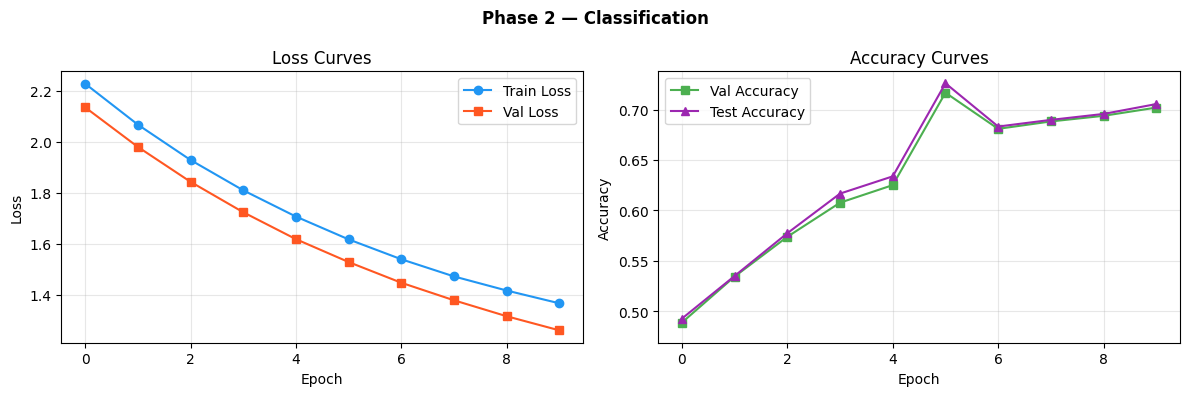

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = history2["epoch"]

ax = axes[0]
ax.plot(epochs, history2["train_loss"], "o-", label="Train Loss", color="#2196F3")
ax.plot(epochs, history2["val_loss"], "s-", label="Val Loss", color="#FF5722")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Loss Curves"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs, history2["val_accuracy"], "s-", label="Val Accuracy", color="#4CAF50")
ax.plot(epochs, history2["test_accuracy"], "^-", label="Test Accuracy", color="#9C27B0")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Curves"); ax.legend(); ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=max(0, min(history2["val_accuracy"]) - 0.02))

plt.suptitle("Phase 2 — Classification", fontweight="bold")
plt.tight_layout()
plt.show()

In [12]:
tracker2.finalize()
print(f"Phase 2 run: {tracker2.run_id}")

# Final evaluation
val_loss, val_acc = evaluate(val_loader)
test_loss, test_acc = evaluate(test_loader)
print(f"\nFinal val accuracy:  {val_acc:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")

# Silhouette score on test set hidden activations
hidden_acts, hidden_labels = [], []
hook_out = {}
def _hook(module, inp, out):
    hook_out['act'] = inp[0].detach()
handle = model.fc3.register_forward_hook(_hook)
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        model(x)
        hidden_acts.append(hook_out['act'].numpy())
        hidden_labels.append(y.numpy())
handle.remove()

X_hidden = np.concatenate(hidden_acts)
y_hidden = np.concatenate(hidden_labels)
n_sil = min(5000, len(X_hidden))
idx = np.random.RandomState(42).choice(len(X_hidden), n_sil, replace=False)
sil = silhouette_score(X_hidden[idx], y_hidden[idx])
print(f"\nSilhouette score (test, {X_hidden.shape[1]}D hidden): {sil:.4f}")

Finalized run 'cluster_classify_v2' with 94 checkpoints
Phase 2 run: cluster_classify_v2

Final val accuracy:  0.7019
Final test accuracy: 0.7054

Silhouette score (test, 64D hidden): 0.4064
